In [1]:
from pathlib import Path
import sys
import math

planning_path = Path('.').absolute().parents[1] / 'cloud_auto_park' / 'cloud_auto_park'
controls_path = Path('.').absolute().parents[0] / 'vehicle_controller'

sys.path.append(str(planning_path))
sys.path.append(str(controls_path))

from trajectory_utils import *
from geometry_helpers import *
from mpc import *
import numpy as np
import time, pickle, time


In [2]:
trajectories_data_file = planning_path /'..' / 'analysis' / 'data' / 'trajectories.pkl'
trajectories = []
with open(str(trajectories_data_file), 'rb') as f:
    trajectories = pickle.load(f)


In [3]:
MIN_SPEED = 0.001

class VehiclePlantModel:
    
    def __init__(self, params: VehicleBicycleModelParams, major_sample_time_s=0.02, sample_time_s=0.005):
        self.params = params
        self.sample_time_s = sample_time_s
        self.major_sample_time_s = major_sample_time_s
        self.curr_state = np.array([[0.0], [0.0]])
        self.curr_pose = np.array([[0.0], [0.0], [0.0]])
        
    def get_a_b(self, vx_mps):
    
        if vx_mps >= 0: vx_mps = max(vx_mps, MIN_SPEED)
        else: vx_mps = min(vx_mps, -1*MIN_SPEED)
        abs_vx = abs(vx_mps)
        cf_Nprad = self.params.cf_Nprad
        cr_Nprad = self.params.cr_Nprad
        mass_kg = self.params.mass_kg
        lf_m = self.params.lf_m
        lr_m = self.params.lr_m
        izz_kgm2 = self.params.izz_kgm2
        
        A = np.array([
            [ -(cf_Nprad + cr_Nprad) / (mass_kg * abs_vx), (cr_Nprad*lr_m - cf_Nprad*lf_m)/(mass_kg*abs_vx) - vx_mps ],
            [ (lr_m*cr_Nprad - lf_m*cf_Nprad) / (izz_kgm2*abs_vx), -(lf_m * lf_m * cf_Nprad + lr_m * lr_m * cr_Nprad)/(izz_kgm2*abs_vx) ]
        ])
        B = np.array([
            [(cf_Nprad*vx_mps)/(mass_kg*abs_vx)],
            [(cf_Nprad*lf_m*vx_mps)/(abs_vx*izz_kgm2)]
        ])
    
        return A, B
    
    def step_simulation(self, state, pose, delta, speed_mps):
        
        # using forward euler, may need to make this rk4 later
        A, B = self.get_a_b(speed_mps)
        state_dot = A @ state + B * delta
        state += state_dot * self.sample_time_s
        
        # get vx, vy, yaw rate, and update ego pose
        vx = speed_mps
        vy = state[0]
        yaw_rate = state[1]
        yaw = pose[2]
        
        vx_prime = vx*np.cos(yaw) - vy*np.sin(yaw)
        vy_prime = vx*np.sin(yaw) + vy*np.cos(yaw)
        
        pose_dot = np.array([vx_prime, vy_prime, yaw_rate])
        # print('plant pose dot', pose_dot)
        # print('=======')
        # print('plant pose', pose)
        pose += pose_dot * self.sample_time_s
        
        return state, pose
    
    def simulate_over_horizon(self, deltas, speeds_mps):
        
        N = len(deltas)
        for i in range(N):
            self.curr_state, self.curr_pose = self.step_simulation(self.curr_state, self.curr_pose, deltas[i], speeds_mps[i])
    
    def step(self, delta, speed_mps):
        num_timesteps = int(self.major_sample_time_s // self.sample_time_s)
        # print('num timesteps:', num_timesteps)
        deltas = [delta] * num_timesteps
        speeds = [speed_mps] * num_timesteps
        self.simulate_over_horizon(deltas, speeds)
        
    def get_curr_pose(self): return self.curr_pose
    def get_curr_state(self): return self.curr_state
        

In [4]:
# MPC PARAMS
actual_params = VehicleBicycleModelParams(cf_Nprad=3.30, cr_Nprad=3.80, mass_kg=2.62, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.062)
speed_mps = -1.0
sample_time_hz = 50
horizon = 10
delta_ff = []

lr = actual_params.lr_m
lf = actual_params.lf_m
m=actual_params.mass_kg
Iz = actual_params.izz_kgm2
cf = actual_params.cf_Nprad
cr = actual_params.cr_Nprad

fig_save_path = 'figures/doe/'

def get_parked_status_string(parked, pseudoparked, collided):
    if parked: return 'Parked'
    elif pseudoparked: return 'Pseudo-Parked'
    elif collided: return 'Collided'
    else: return 'Not Parked'

def get_acceptable_region(obb_1: OrientedBoundingBox, obb_2: OrientedBoundingBox):
    
    return OrientedBoundingBox(
        (obb_1.centroid_x_m + obb_2.centroid_x_m) / 2,
        (obb_1.centroid_y_m + obb_2.centroid_y_m) / 2,
        (obb_1.length_m + obb_2.length_m) / 2 + 0.8,
        abs(obb_2.centroid_x_m - obb_1.centroid_x_m) - (obb_1.width_m + obb_2.width_m) / 2 - 0.6,
        math.pi/2
    ), OrientedBoundingBox(
        (obb_1.centroid_x_m + obb_2.centroid_x_m) / 2,
        (obb_1.centroid_y_m + obb_2.centroid_y_m) / 2,
        (obb_1.length_m + obb_2.length_m) / 2 + 0.8,
        abs(obb_2.centroid_x_m - obb_1.centroid_x_m) - (obb_1.width_m + obb_2.width_m) / 2,
        math.pi/2
    )
    
    
def get_parked_status(final_ego_obb: OrientedBoundingBox, target_obb: OrientedBoundingBox, acceptable_region_obb: OrientedBoundingBox, pseudoacceptable_region_obb: OrientedBoundingBox, min_sep):
    
    heading_offset_rad = (3 * math.pi / 180)
    
    is_heading_aligned = (abs(target_obb.heading_rad - final_ego_obb.heading_rad) <= heading_offset_rad)
    
    final_ego_bbox = OrientedBoundingBox(final_ego_obb.centroid_x_m, final_ego_obb.centroid_y_m, final_ego_obb.length_m, final_ego_obb.width_m, final_ego_obb.heading_rad)
    is_ego_in_acceptable_region = is_obb_contained(acceptable_region_obb, final_ego_bbox)
    is_ego_in_pseudoacceptable_region = is_obb_contained(pseudoacceptable_region_obb, final_ego_bbox)
    
    is_collided = (min_sep < 0.0)
    
    return {
        'parked': (is_heading_aligned and is_ego_in_acceptable_region and (not is_collided)),
        'pseudoparked': (is_ego_in_pseudoacceptable_region and (not is_collided)),
        'collided': is_collided
    }

def plot_ego_traj(trajectory, stats, obstacles, desired_pose, metrics, metadata, num_intermediate_ego=30):
    
    def get_obstacle_patch(obb: OrientedBoundingBox, color='blue', alpha=0.6, linewidth=2, zorder=-999, linestyle='-'):
        
        lower_left_x = obb.centroid_x_m - (obb.length_m / 2)
        lower_left_y = obb.centroid_y_m + (obb.width_m / 2)
        
        edgecolor, facecolor = '', ''
        if color == 'blue':
            edgecolor = 'blue'
            facecolor = 'lightblue'
        elif color == 'darkblue':
            edgecolor = 'darkblue'
            facecolor = 'blue'
        elif color == 'orange':
            edgecolor = 'red'
            facecolor = 'orange'
        elif color == 'red':
            edgecolor = 'darkred'
            facecolor = 'red'
        elif color == 'green_clear':
            edgecolor = 'green'
            facecolor = 'none'
        
        rect = matplotlib.patches.Rectangle(
            xy=(-lower_left_y, lower_left_x),
            width=obb.width_m,
            height=obb.length_m,
            angle=np.degrees(obb.heading_rad),
            rotation_point='center',  # Instructs matplotlib to rotate around the center
            edgecolor=edgecolor,
            facecolor=facecolor,
            alpha=alpha,
            linewidth=linewidth,
            zorder=zorder,
            linestyle=linestyle
        )
        return rect
    
    fig, ax = plot_desired_path(trajectory, obstacles, num_intermediate_ego=0, plot_desired=False)
    ax.plot(-stats['y'], stats['x'], c='black', marker='o', markersize=2, label='Ego Vehicle Path')
    
    # plot intermediate ego vehicle obbs along the trajectory
    for ego_idx in range(num_intermediate_ego):
        N = len(stats['x'])
        path_idx = int((N-1) * ego_idx / (num_intermediate_ego - 1))
        # print(path_idx)
        
        intermediate_ego_obb = OrientedBoundingBox(stats['x'][path_idx], stats['y'][path_idx], desired_pose.length_m, desired_pose.width_m, stats['theta'][path_idx])
        intermediate_ego_rect = get_obstacle_patch(intermediate_ego_obb, 'blue', 0.15)
        ax.add_patch(intermediate_ego_rect)
        
    # plot acceptable final region
    parking_region_obb, parking_pseudoregion_obb = get_acceptable_region(obstacles[0], obstacles[1])
    parking_region_rect = get_obstacle_patch(parking_region_obb, color='green_clear', alpha=1.0, zorder=999, linestyle='--', linewidth=3)
    parking_region_rect.set_label('Parking Region')
    ax.add_patch(parking_region_rect)
    
    ax.legend()
    
    # construct filename from metadata
    dir_string = 'left' if metadata['is_left'] else 'right'
    wall_string = 'wall' if metadata['is_wall'] else 'nowall'
    park_status_string = get_parked_status_string(metrics['parked'], metrics['pseudoparked'], metrics['collided'])
    filename = f"controls_gap_{metadata['gap_dist']:.2f}_xsep_{metadata['x_sep']:.2f}_ysep_{metadata['y_sep']:.2f}_{dir_string}_{wall_string}_viz_{park_status_string}"
    filename = filename.replace('.', '-')
    filename = filename.replace(' ', '_')
    
    # construct figure title/subtitle from metadata
    dir_string = 'Left' if metadata['is_left'] else 'Right'
    wall_string = 'with Wall' if metadata['is_wall'] else 'without Wall'
    title_string = f'Controls DOE - {dir_string} Park {wall_string} - {park_status_string}'
    subtitle_string = f"$d_{{gap}} = {(metadata['gap_dist'] - 2):.2f}$m, $d_x = {(metadata['x_sep']):.2f}$m, $d_y = {(metadata['y_sep']):.2f}$m"
    
    fig.suptitle(title_string)
    ax.set_title(subtitle_string)
    fig.savefig(fig_save_path + filename + '.svg')
    plt.close(fig)
    
def plot_controls_stats(trajectory, stats, metrics, metadata):
    
    # abs(trajectories[0].headings - stats['theta'])
    x_vals = np.array(list(range(len(trajectory.headings)))) / sample_time_hz
    
    # construct figure title/subtitle from metadata
    dir_string = 'Left' if metadata['is_left'] else 'Right'
    wall_string = 'with Wall' if metadata['is_wall'] else 'without Wall'
    park_status_string = get_parked_status_string(metrics['parked'], metrics['pseudoparked'], metrics['collided'])
    title_string = f'Controls DOE Metrics - {dir_string} Park {wall_string} - {park_status_string}'
    subtitle_string = f"$d_{{gap}} = {(metadata['gap_dist'] - 2):.2f}$m, $d_x = {(metadata['x_sep']):.2f}$m, $d_y = {(metadata['y_sep']):.2f}$m"

    fig, ax = plt.subplots(5, sharex=True)
    fig.suptitle(title_string)
    ax[-1].set_xlabel('Time (s)')
    ax[0].set_title(subtitle_string)

    ds = np.sqrt(np.square(trajectory.path[0] - stats['x']) + np.square(trajectory.path[1] - stats['y']))
    ax[0].plot(x_vals, ds, label='Path Deviation (m)')
    ax[0].set_ylabel('Path Deviation (m)')

    # abs(trajectories[0].headings - stats['theta'])
    ax[1].plot(x_vals, trajectory.headings, label='Desired Heading (rad)')
    ax[1].plot(x_vals, stats['theta'], label='Actual Heading (rad)')
    ax[1].set_ylabel('Heading (rad)')

    ax[2].plot(x_vals, trajectory.curvatures * speed_mps, label='Desired Yaw Rates (rad/s)')
    ax[2].plot(x_vals, stats['omega'], label='Desired Yaw Rates (rad/s)')
    ax[2].set_ylabel('Yaw Rate (rad/s)')

    ax[3].plot(x_vals, stats['delta_ff'], label='Feedforward RWA (rad)')
    ax[3].plot(x_vals, stats['delta'], label='Actual RWA (rad)')
    ax[3].set_ylabel('RWA (rad)')
    
    ax[4].plot(x_vals, stats['solve_times'], label='Solve Times (s)')
    ax[4].axhline(y=0.02, color='red', linestyle='--', linewidth=1.2, label='Max Solve Time (s)')
    ax[4].set_ylabel('Solve Time (s)')

    for a in ax:
        a.legend()
        a.grid()

    fig.set_size_inches(10, 8)
    fig.set_tight_layout(True)
    
    dir_string = 'left' if metadata['is_left'] else 'right'
    wall_string = 'wall' if metadata['is_wall'] else 'nowall'
    filename = f"controls_gap_{metadata['gap_dist']:.2f}_xsep_{metadata['x_sep']:.2f}_ysep_{metadata['y_sep']:.2f}_{dir_string}_{wall_string}_graphs_{park_status_string}"
    filename = filename.replace('.', '-')
    filename = filename.replace(' ', '_')
    fig.savefig(fig_save_path + filename + '.svg')
    plt.close(fig)

def get_metrics(trajectory, stats, obstacles, desired_obb):
    
    # Get RMSE of path error
    ds = np.sqrt(np.square(trajectory.path[0] - stats['x']) + np.square(trajectory.path[1] - stats['y']))
    
    # Get heading deviations
    dtheta = trajectory.headings - stats['theta']
    
    # Create a Trajectory object from the vehicle's path and use it to get min distance between ego and obstacles
    ego_traj = Trajectory(np.array([stats['x'], stats['y']]), stats['theta'], stats['omega']/speed_mps, [], desired_pose)
    min_sep = math.inf
    for obs in obstacles:
        sep = get_min_separation_between_traj_and_obs(ego_traj, obs, 50)
        if sep < min_sep:
            min_sep = sep
            
    # get parked/pseudoparked status (ISO 16787)
    final_ego_obb = OrientedBoundingBox(stats['x'][-1], stats['y'][-1], desired_obb.length_m, desired_obb.width_m, stats['theta'][-1])
    acceptable_parking_obb, parking_pseudoregion_obb = get_acceptable_region(obstacles[0], obstacles[1])
    parking_status = get_parked_status(final_ego_obb, desired_obb, acceptable_parking_obb, parking_pseudoregion_obb, min_sep)
    
    return {
        'mean_path_deviation': np.mean(ds),
        'max_path_deviation': np.max(ds),
        'final_path_deviation': ds[-1],
        'final_heading_deviation': dtheta[-1],
        'final_pose': [stats['x'][-1], stats['y'][-1], stats['theta'][-1]],
        'mean_solve_time': np.mean(stats['solve_times']),
        'max_solve_time': np.max(stats['solve_times']),
        'min_sep': min_sep,
        'parked': parking_status['parked'],
        'pseudoparked': parking_status['pseudoparked'],
        'collided': parking_status['collided']
    }

def follow_trajectory_and_get_metrics(metadata):
    
    # unpack the metadata (trajectory, obstacles, desired pose)
    trajectory = metadata['traj']
    desired_pose, obstacles = setup_scenario(**metadata)
    
    # setup mpc controller
    mpc = MpcController(actual_params, sample_time_hz=15, horizon=horizon, speed_mps=speed_mps)
    mpc.set_path(trajectory.path, trajectory.headings, trajectory.curvatures)
    plant = VehiclePlantModel(actual_params, major_sample_time_s=(1/sample_time_hz))
    
    # step through number of timesteps in vehicle path
    curr_pose = np.array([[0.0], [0.0], [0.0]])

    # run through scenario and record stats
    xs, ys, thetas, deltas, omegas, solve_times = [], [], [], [], [], []
    for i in range(len(trajectory.curvatures)):
        
        # step controller
        mpc.set_curr_pose(curr_pose)
        start_time = time.process_time()
        curr_delta = mpc.step()
        end_time = time.process_time()
        
        # step plant
        plant.step(curr_delta, speed_mps)
        curr_pose = plant.get_curr_pose()
        curr_state = plant.get_curr_state()
        
        # save stats
        xs.append(float(curr_pose[0]))
        ys.append(float(curr_pose[1]))
        thetas.append(float(curr_pose[2]))
        omegas.append(float(curr_state[1]))
        deltas.append(float(curr_delta))
        solve_times.append(end_time - start_time)
        
    # put stats in a dict
    stats = {
        'x': np.array(xs),
        'y': np.array(ys),
        'theta': np.array(thetas),
        'omega': np.array(omegas),
        'delta': np.array(deltas),
        'delta_ff': np.array(mpc.ff_delta_history),
        'solve_times': np.array(solve_times)
    }
    
    # get metrics from stats
    metrics = get_metrics(trajectory, stats, obstacles, desired_pose)
    
    # do plotting utils
    plot_controls_stats(trajectory, stats, metrics, metadata)
    plot_ego_traj(trajectory, stats, obstacles, desired_pose, metrics, metadata)
    
    return {
        'stats': stats,
        'metrics': metrics
    }


In [25]:
import itertools

def setup_scenario(gap_dist, x_sep, y_sep, is_left, is_wall, traj):
    
    obstacle_sep = gap_dist
    sign = 1 if is_left else -1
    obb_1 = OrientedBoundingBox(-x_sep, sign * y_sep, 4.0, 2.0, math.pi/2)
    obb_2 = OrientedBoundingBox(-x_sep - obstacle_sep, sign * y_sep, 4.0, 2.0, math.pi/2)
    wall = OrientedBoundingBox(-5.0, -sign * 2.5, 12.0, 1.0, 0.0)
    
    obstacles = [obb_1, obb_2]
    if is_wall: obstacles.append(wall)
    
    desired_pose = OrientedBoundingBox(-x_sep - (obstacle_sep / 2.0), sign * y_sep, 4.0, 2.0, -sign * math.pi/2)
    
    return desired_pose, obstacles


gap_dists = [4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
x_seps = [1.0, 2.0, 3.0, 4.0]
y_seps = [3.5, 4.0, 4.5, 5.0]
walls = [True, False]
directions = [True, False]
combinations = list(itertools.product(gap_dists, x_seps, y_seps, walls, directions))
print(len(combinations))

# setup all combinations for doe
scenarios = []
all_obstacles = []
all_desired_poses = []
for idx, combo in enumerate(combinations):
    metadata = {
        'gap_dist': combo[0], 
        'x_sep': combo[1], 
        'y_sep': combo[2], 
        'is_left': combo[3], 
        'is_wall': combo[4],
        'traj': trajectories[idx]
    }
    scenarios.append(metadata)

for scenario in scenarios:
    desired_pose, obstacles = setup_scenario(**scenario)
    all_desired_poses.append(desired_pose)
    all_obstacles.append(obstacles)

def run_planning_metrics(traj, obstacles):
    
    # thresholds
    cf=3.30; cr=3.80; m=2.62; lf=0.15875; lr=0.17145; iz=0.062; vx=1; delta_max = 0.3
    K_max = delta_max / ((lf + lr) + (m / (lf + lr))*(lr/(cf) - lf/(cr))*(vx)*(vx))
    D_min = 0.25
    
    min_separation = math.inf
    # for each obstacle, get closest distance between ego following trajectory and the obstacle
    for idx, obstacle_obb in enumerate(obstacles):
        separation = get_min_separation_between_traj_and_obs(traj, obstacle_obb)
        if separation < min_separation:
            min_separation = separation
        
    max_abs_curv = np.max(np.abs(traj.curvatures))
    
    # feasibility checks
    feas = (min_separation > D_min) and (max_abs_curv <= K_max)
    pseudofeas = (min_separation > 0) and (max_abs_curv <= K_max)
    
    return {'min_separation': min_separation, 'max_abs_curv': max_abs_curv, 'feas': feas, 'pseudofeas': pseudofeas}

planning_metrics = [run_planning_metrics(trajectories[i], all_obstacles[i]) for i in range(len(trajectories))]


384


In [6]:
stats_and_metrics = follow_trajectory_and_get_metrics(scenarios[200])


/project/project/sim_ws/src/digital_twin/vehicle_controller/vehicle_controller/mpc.py:33: TookTooLong: Terminating optimization: time limit reached
  warnings.warn("Terminating optimization: time limit reached",
/usr/local/lib/python3.8/dist-packages/scipy/optimize/_optimize.py:353: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


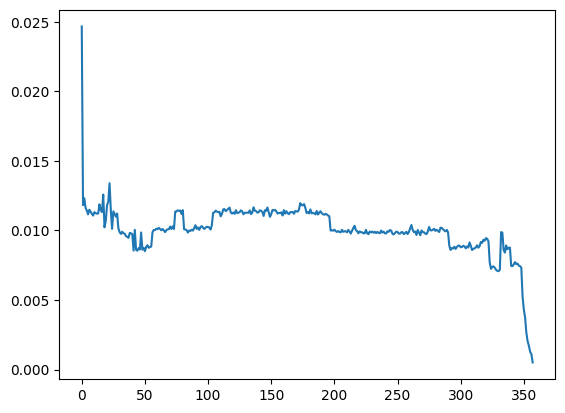

In [7]:
plt.plot(stats_and_metrics['stats']['solve_times'])


In [8]:
import multiprocessing as mp
import pickle, asyncio

results = {}
run_doe = False

if run_doe:
    # Determine your system's core count
    # cores = mp.cpu_count() // 2

    # with mp.Pool(processes=cores) as pool:
    #     results = pool.map(follow_trajectory_and_get_metrics, scenarios)

    results = []
    for idx, scenario in enumerate(scenarios):
        results.append(follow_trajectory_and_get_metrics(scenario))
        if idx % 10 == 0: print(idx)
        await asyncio.sleep(1.0)
    
    # save dataframe for future analysis
    with open(f'data/results.pkl', 'wb') as f:
        pickle.dump(results, f)


0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380


In [19]:
results[0]['metrics']


{'mean_path_deviation': 0.0886241228573833,
 'max_path_deviation': 0.13824179645174095,
 'final_path_deviation': 0.13824179645174095,
 'final_heading_deviation': -0.0003474502490976583,
 'final_pose': [-3.223742726837484, 3.6266453632260385, -1.5704287981267737],
 'mean_solve_time': 0.01058818043598617,
 'max_solve_time': 0.04962910199999904,
 'min_sep': -0.09964113187744061,
 'parked': False,
 'pseudoparked': False,
 'collided': True}

In [88]:
import pandas as pd

gap_dists = [s['gap_dist'] for s in scenarios]
traj_max_abs_curv = [p['max_abs_curv'] for p in planning_metrics]
traj_feas = [p['feas'] for p in planning_metrics]
traj_psueofeas = [p['pseudofeas'] for p in planning_metrics]
mean_path_deviations = [r['metrics']['mean_path_deviation'] for r in results]
final_path_deviations = [r['metrics']['final_path_deviation'] for r in results]
final_heading_deviations = [r['metrics']['final_heading_deviation'] for r in results]
mean_solve_times = [r['metrics']['mean_solve_time'] for r in results]
max_solve_times = [r['metrics']['max_solve_time'] for r in results]
min_seps = [r['metrics']['min_sep'] for r in results]
is_parked = [r['metrics']['parked'] for r in results]
is_pseudoparked = [r['metrics']['pseudoparked'] for r in results]
is_collided = [r['metrics']['collided'] for r in results]

results_df = pd.DataFrame(
    dict(zip(
        ['gap_dists', 'traj_max_abs_curv', 'traj_feas', 'traj_psueofeas', 'mean_path_deviations', 'final_path_deviations', 'final_heading_deviations', 'mean_solve_times', 'max_solve_times', 'min_seps', 'is_parked', 'is_pseudoparked', 'is_collided'],
        [gap_dists, traj_max_abs_curv, traj_feas, traj_psueofeas, mean_path_deviations, final_path_deviations, final_heading_deviations, mean_solve_times, max_solve_times, min_seps, is_parked, is_pseudoparked, is_collided]
    ))
)


In [89]:
results_df


,gap_dists,traj_max_abs_curv,traj_feas,traj_psueofeas,mean_path_deviations,final_path_deviations,final_heading_deviations,mean_solve_times,max_solve_times,min_seps,is_parked,is_pseudoparked,is_collided
0,4.5,0.515379,False,False,0.088624,0.138242,-0.000347,0.010588,0.049629,-0.099641,False,False,True
1,4.5,1.647575,False,False,0.255719,0.284671,0.000132,0.009750,0.013906,-0.141095,False,False,True
2,4.5,0.515380,False,False,0.088624,0.138242,0.000347,0.010487,0.012547,-0.099640,False,False,True
3,4.5,1.647028,False,False,0.255321,0.283952,-0.000129,0.009510,0.013145,-0.140687,False,False,True
4,4.5,0.421263,False,False,0.080514,0.115918,0.000429,0.010226,0.012039,-0.039837,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,7.0,0.395735,True,True,0.083995,0.139539,0.000423,0.010110,0.013759,1.357313,True,True,False
380,7.0,0.503447,True,True,0.105816,0.096983,0.001469,0.009244,0.011693,0.664759,True,True,False
381,7.0,0.391707,True,True,0.091369,0.170629,-0.000821,0.009689,0.012551,1.365293,True,True,False
382,7.0,0.514799,True,True,0.107324,0.097569,-0.001408,0.009386,0.018516,0.670189,True,True,False


In [ ]:
bin_width = 0.2
num_bins = 5
curvs = [[(i+1)*bin_width, (i+2)*bin_width] for i in range(num_bins)] + [[1.2, 10.0]]
curv_data_labels=[f'[{c[0]:.2f}, {c[1]:.2f})' for c in curvs]
curv_data_labels[-1] = f'>={curvs[-1][0]:.2f}'
curv_data_groups = []

gaps = [4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
gap_data_groups = []

for curv in curvs:
    curv_data = results_df[(results_df['traj_max_abs_curv'] >= curv[0]) & (results_df['traj_max_abs_curv'] < curv[1])]
    curv_data_groups.append(curv_data)

for gap in gaps:
    gap_data = results_df[(results_df['gap_dists'] == gap)]
    gap_data_groups.append(gap_data)


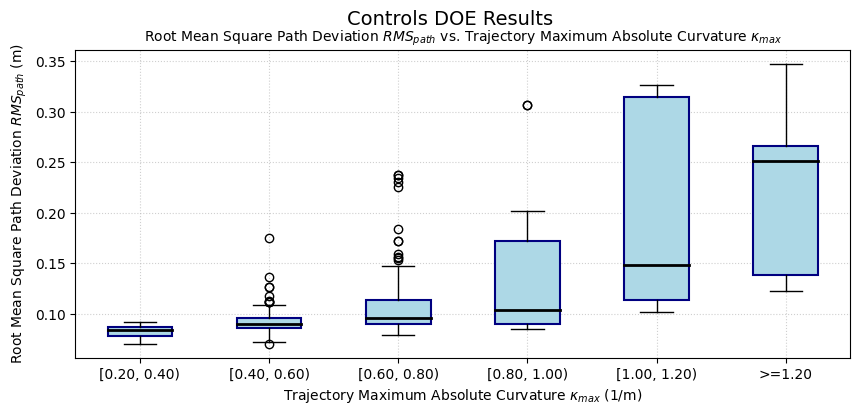

In [95]:
import matplotlib.pyplot as plt

plt.gcf().set_size_inches(10, 4)

plt.boxplot([group['mean_path_deviations'] for group in curv_data_groups], labels=curv_data_labels,
            patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 2},
            boxprops=dict(facecolor='lightblue', color='navy', linewidth=1.5))

plt.grid(True, linestyle=':', alpha=0.6)
plt.xlabel('Trajectory Maximum Absolute Curvature $\kappa_{max}$ (1/m)')
plt.ylabel('Root Mean Square Path Deviation $RMS_{path}$ (m)')
# plt.legend(loc='upper left')
plt.suptitle('Controls DOE Results', fontsize=14)
plt.gca().set_title('Root Mean Square Path Deviation $RMS_{path}$ vs. Trajectory Maximum Absolute Curvature $\kappa_{max}$', fontsize=10)
plt.savefig('figures/controls_doe_rms_path_boxplot.svg')



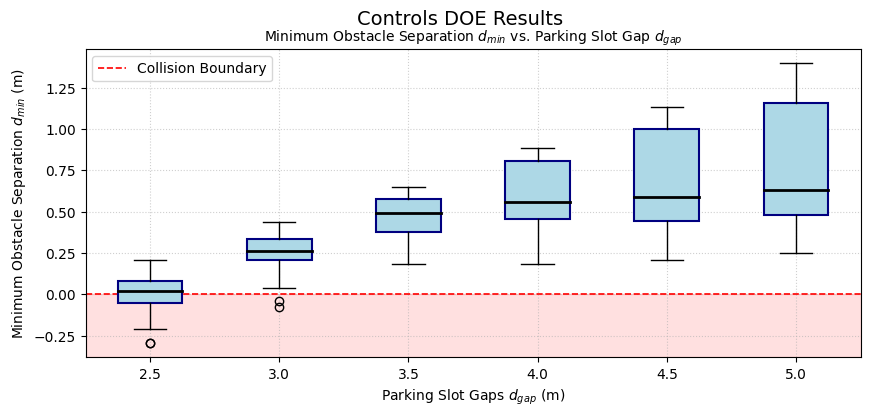

In [98]:
CAR_WIDTH = 2.0

plt.gcf().set_size_inches(10, 4)

plt.axhline(y=0, color='red', linestyle='--', linewidth=1.2, label='Collision Boundary')
# plt.axhline(y=D_min, color='darkorange', linestyle='--', linewidth=1.2, label='Infeasibility Boundary')

plt.boxplot([group['min_seps'] for group in gap_data_groups], labels=[g - CAR_WIDTH for g in gaps],
            patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 2},
            boxprops=dict(facecolor='lightblue', color='navy', linewidth=1.5))

ymin, ymax = plt.ylim()

plt.axhspan(ymin=ymin, ymax=0, color='red', alpha=0.12, zorder=-999)
# plt.axhspan(ymin=0, ymax=D_min, color='orange', alpha=0.12, zorder=-998)

plt.ylim(ymin, ymax)

plt.grid(True, linestyle=':', alpha=0.6)
plt.xlabel('Parking Slot Gaps $d_{gap}$ (m)')
plt.ylabel('Minimum Obstacle Separation $d_{min}$ (m)')
plt.legend(loc='upper left')
plt.suptitle('Controls DOE Results', fontsize=14)
plt.gca().set_title('Minimum Obstacle Separation $d_{min}$ vs. Parking Slot Gap $d_{gap}$', fontsize=10)
plt.savefig('figures/controls_doe_minsep_boxplot.svg')


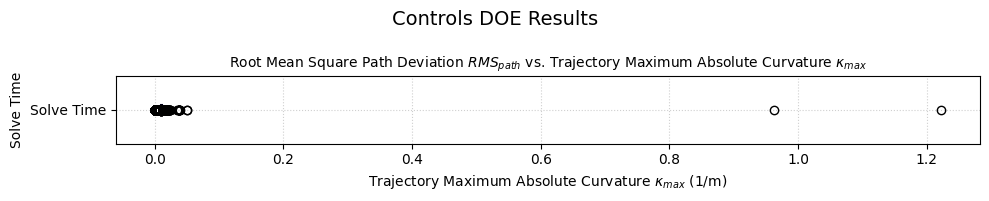

In [ ]:
import matplotlib.pyplot as plt

plt.gcf().set_size_inches(10, 2)

all_solve_times = []
for r in results:
    all_solve_times += list(r['stats']['solve_times'])

plt.boxplot(all_solve_times, labels=['Solve Time'],
            patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 2},
            boxprops=dict(facecolor='lightblue', color='navy', linewidth=1.5), vert=False)

plt.grid(True, linestyle=':', alpha=0.6)
plt.xlabel('Solve Time (s)')
plt.ylabel('Solve Time')
# plt.legend(loc='upper left')
plt.suptitle('Controls DOE Results', fontsize=14)
plt.gca().set_title('Controller Solve Times', fontsize=10)
plt.gcf().set_tight_layout(True)
plt.savefig('figures/controls_doe_rms_path_boxplot.svg')


In [131]:
print('Results broken down by max abs curv'.upper())
curv_data_groups_and_everything = curv_data_groups + [results_df]
for idx, label in enumerate(curv_data_labels + ['AGGREGATE']):
    g = curv_data_groups_and_everything[idx]
    print('============== ' + label + ' ================')
    print(f'mean RMS path deviation: {np.mean(g["mean_path_deviations"]):.3f}')
    print(f'mean final path deviation: {np.mean(g["final_path_deviations"]):.3f}')
    print(f'mean abs final heading deviation: {np.mean(np.abs(g["final_heading_deviations"])):.5f}')
    print(f'mean mean solve times: {np.mean(g["mean_solve_times"]):.3f}')
    print(f'mean min gap: {np.mean(g["min_seps"]):.3f}')
    print(f'parked percentage (all): {np.mean(g["is_parked"] * 100):.3f}')
    print(f'parked percentage (traj feas): {np.mean(g[g["traj_feas"]]["is_parked"]) * 100:.3f}')
    print(f'psuedoparked percentage: {np.mean(g["is_pseudoparked"] * 100):.3f}')
    print(f'collided percentage: {np.mean(g["is_collided"] * 100):.3f}')


RESULTS BROKEN DOWN BY MAX ABS CURV
============== [0.20, 0.40) ================
mean RMS path deviation: 0.083
mean final path deviation: 0.135
mean abs final heading deviation: 0.00066
mean mean solve times: 0.010
mean min gap: 0.689
parked percentage (all): 94.643
parked percentage (traj feas): 100.000
psuedoparked percentage: 100.000
collided percentage: 0.000
============== [0.40, 0.60) ================
mean RMS path deviation: 0.092
mean final path deviation: 0.124
mean abs final heading deviation: 0.00075
mean mean solve times: 0.010
mean min gap: 0.530
parked percentage (all): 92.553
parked percentage (traj feas): 100.000
psuedoparked percentage: 96.809
collided percentage: 3.191
============== [0.60, 0.80) ================
mean RMS path deviation: 0.112
mean final path deviation: 0.149
mean abs final heading deviation: 0.00087
mean mean solve times: 0.010
mean min gap: 0.305
parked percentage (all): 72.043
parked percentage (traj feas): 100.000
psuedoparked percentage: 84.946


In [135]:
print('Results broken down by parking gap'.upper())
gap_data_groups_and_everything = gap_data_groups + [results_df]
for idx, label in enumerate([g - CAR_WIDTH for g in gaps] + ['AGGREGATE']):
    g = gap_data_groups_and_everything[idx]
    print('============== ' + str(label) + ' ================')
    print(f'mean RMS path deviation: {np.mean(g["mean_path_deviations"]):.3f}')
    print(f'mean final path deviation: {np.mean(g["final_path_deviations"]):.3f}')
    print(f'mean abs final heading deviation: {np.mean(np.abs(g["final_heading_deviations"])):.5f}')
    print(f'mean mean solve times: {np.mean(g["mean_solve_times"]):.3f}')
    print(f'mean min gap: {np.mean(g["min_seps"]):.3f}')
    print(f'parked percentage (all): {np.mean(g["is_parked"] * 100):.3f}')
    print(f'parked percentage (traj feas): {np.mean(g[g["traj_feas"]]["is_parked"]) * 100:.3f}')
    print(f'psuedoparked percentage: {np.mean(g["is_pseudoparked"] * 100):.3f}')
    print(f'collided percentage: {np.mean(g["is_collided"] * 100):.3f}')


RESULTS BROKEN DOWN BY PARKING GAP
============== 2.5 ================
mean RMS path deviation: 0.136
mean final path deviation: 0.190
mean abs final heading deviation: 0.00082
mean mean solve times: 0.010
mean min gap: 0.004
parked percentage (all): 0.000
parked percentage (traj feas): nan
psuedoparked percentage: 53.125
collided percentage: 43.750
============== 3.0 ================
mean RMS path deviation: 0.114
mean final path deviation: 0.158
mean abs final heading deviation: 0.00067
mean mean solve times: 0.010
mean min gap: 0.251
parked percentage (all): 93.750
parked percentage (traj feas): 100.000
psuedoparked percentage: 93.750
collided percentage: 3.125
============== 3.5 ================
mean RMS path deviation: 0.104
mean final path deviation: 0.148
mean abs final heading deviation: 0.00075
mean mean solve times: 0.010
mean min gap: 0.461
parked percentage (all): 100.000
parked percentage (traj feas): 100.000
psuedoparked percentage: 100.000
collided percentage: 0.000
====